# Week 4 - Probability Distributions 3 and Mixture Models - solution

Learning contents:

1. Histogram-based density estimation
    - Display histogram densities
2. Kernel density estimation
    - Hypercube Kernel function
    - Gaussian Kernel function
3. K-Nearest Neigbours classification
    - Generate data
    - Classification function
    - Display results
4. K-Means clustering
    - Display results

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from collections import Counter
from scipy.stats import norm
from sklearn import datasets
from math import floor

import seaborn as sns; sns.set_theme(); sns.set_palette('bright')

## Generate data

The provided function `generate_data_1D` below returns `size` samples of a single random variable following a mixture of Gaussians distribution with parameters `means`, `stds` (standard deviations) and `pi` (mixture weights). Read the code and make sure you understand how the mixture is sampled. 

In [2]:
def generate_data_1D(size, means, stds, pi):
    """Generate 1D samples from a Gaussian mixture model.

    Parameters
    ----------
    size : int
        Number of samples to generate.
    means : list of float
        Component means (mu_k).
    stds : list of float
        Component standard deviations (sigma_k). Note: these are std devs, NOT variances.
    pi : list of float
        Mixture weights (must sum to 1).

    Returns
    -------
    list of float
        Sampled data points.

    Note
    ----
    Call np.random.seed(...) before this function for reproducible results.
    """
    x = []
    for i in range(size):
        z_i = np.argmax(np.random.multinomial(1, pi))
        x_i = np.random.normal(means[z_i], stds[z_i])
        x.append(x_i)
    return x

The function below generates 1000 data points from the Gaussian mixture distribution and plots their histogram. Observe the plot and comment on whether the plot coincides with the input data.

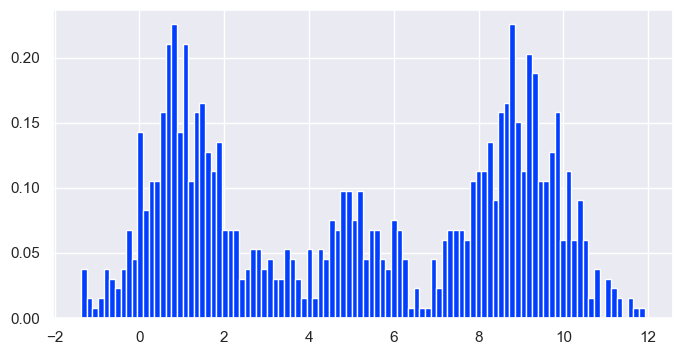

In [3]:
means = [1, 5, 9]
stds = [1, 1, 1]  # standard deviations (sigma_k), not variances
pis = [0.4, 0.2, 0.4]
np.random.seed(10)
data = generate_data_1D(1000, means, stds, pis);

fig, ax = plt.subplots(figsize=(8, 4));
ax.hist(data, bins=100, density=True);

## 1) Histogram-based density estimation

write a function `histogram` that takes input `data`, user-defined bin size `delta` and returns `bins` (list of edges of the bins) and their corresponding `probabilities`. Hint: you can use numpy's histogram function to do so.

In [4]:
def histogram(data, delta):
    n_bins = floor((max(data)-min(data))/delta)
    probs, bins = np.histogram(data, bins = n_bins, density=True) # using numpy's histogram function 
    return bins, probs

### 1.1) Display histogram densities

Display the `histograms` for different values of bin sizes and also compute and plot the `true` probability density (slide 9 of lecture 7) of the data. Compare the two plots and see which values of bin sizes reveal densities that are close to the true density function 

In [5]:
def univariate_normal(x, mean, variance):
    """pdf of the univariate normal distribution."""
    return ((1. / np.sqrt(2 * np.pi * variance)) *
            np.exp(-(x - mean)**2 / (2 * variance)))

def display_histogram_density(data, delta):
    bins, probs = histogram(data, delta)
    a = np.arange(-5, 15, 0.01)
    # True mixture density: sum over components of pi_k * N(x | mean_k, std_k^2)
    y = (pis[0] * univariate_normal(a, mean=means[0], variance=stds[0]**2) +
         pis[1] * univariate_normal(a, mean=means[1], variance=stds[1]**2) +
         pis[2] * univariate_normal(a, mean=means[2], variance=stds[2]**2))

    fig, ax = plt.subplots(figsize=(8, 4))
    # Bars must span exactly their bins: anchor each bar at its left edge
    # (align='edge') and use the true bin widths from np.histogram (~delta).
    ax.bar(bins[:-1], probs, width=np.diff(bins), align='edge')
    ax.plot(a, y, '-r')

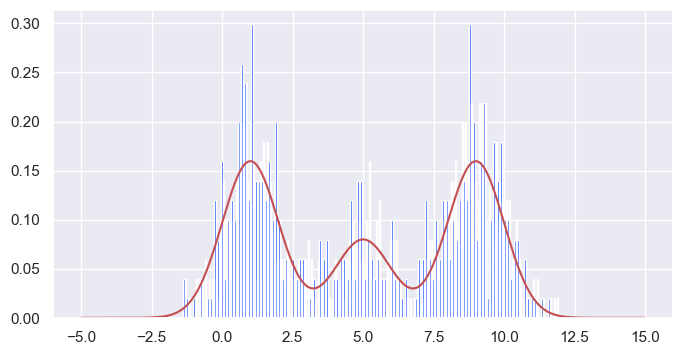

In [6]:
display_histogram_density(data, 0.05)

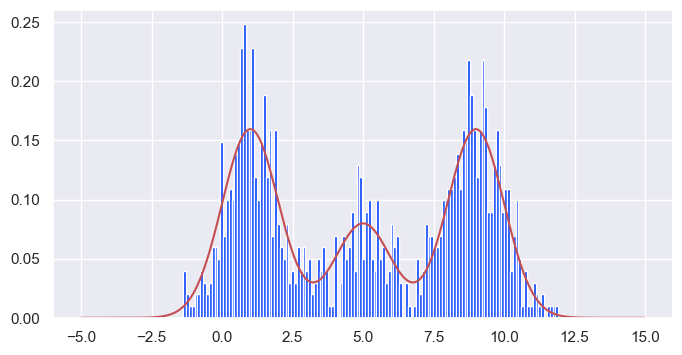

In [7]:
display_histogram_density(data, 0.1)

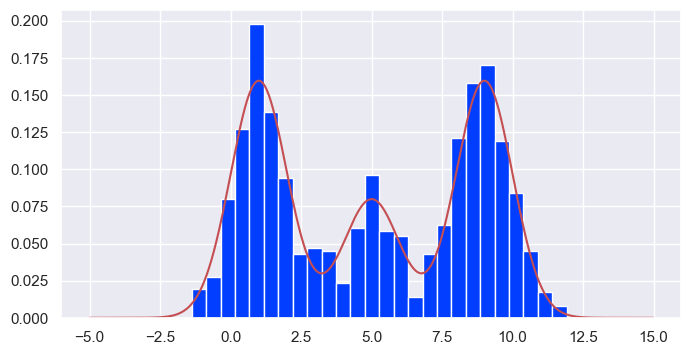

In [8]:
display_histogram_density(data, 0.5)

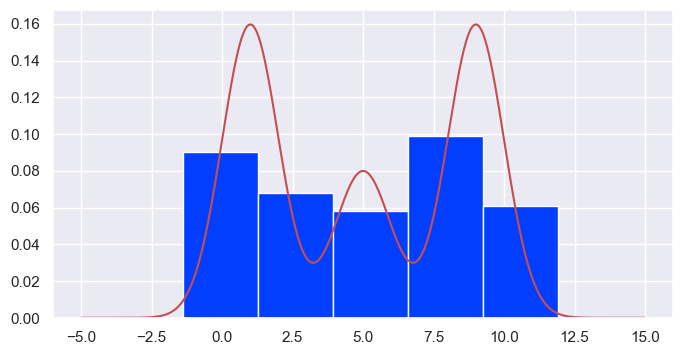

In [9]:
display_histogram_density(data, 2.5)

## 2) Kernel density estimation

### 2.1) Hypercube Kernel function

write a function `hypercube_kernel_function` takes `u` and returns 0 or 1 if `u` is inside 1/2 hypercube (see slide 18 of lecture 7).

In [10]:
def hypercube_kernel_function(u):
    return 1 if all(abs(u) <= 1/2) else 0

write the function `hypercube_kernel_density` that takes a single data point `x`, training data points `data`, size of a cube `h`, data dimensions `D` and returns the probability density of `x` based on the Hypercube kernel function (see the first equation on slide 19 of lecture 7)

In [11]:
def hypercube_kernel_density(x, data, h, D):
    
    result = 0
    
    for x_n in data:
        result += hypercube_kernel_function(((x - x_n) / h).reshape(-1))
    
    result /= len(data) * (h ** D)
    return result

display the computed nonparametric density estimates for different values of `h`. What is the effect of `h` on density estimates?

In [12]:
def display_hypercube_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: hypercube_kernel_density(x, data, h, 1), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

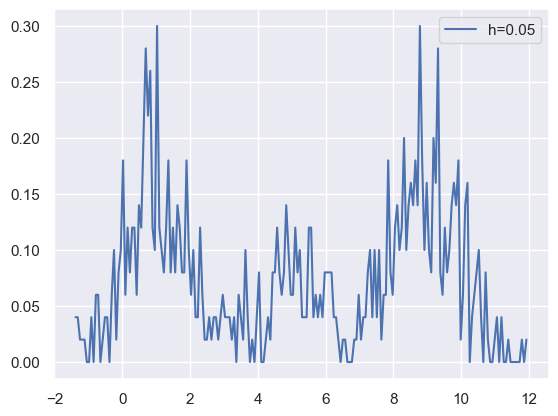

In [13]:
display_hypercube_kernel_density_1D(data, 0.05, 'b')

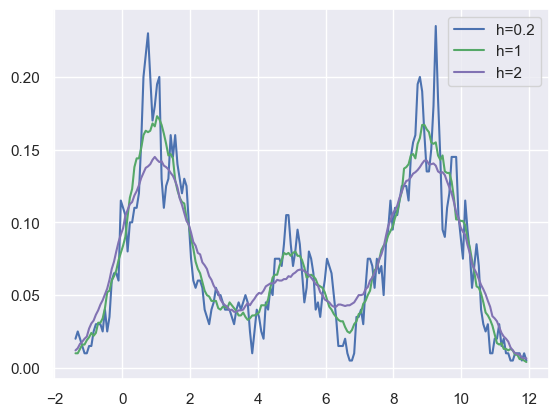

In [14]:
display_hypercube_kernel_density_1D(data, 0.2, 'b')
display_hypercube_kernel_density_1D(data, 1, 'g')
display_hypercube_kernel_density_1D(data, 2, 'm')

### 2.2) Gaussian Kernel function

Write the function `gaussian_kernel_function` that takes pair of points `x` and `x_n`, size `h` and returns Gaussian kernel function value for the pair of points.

In [15]:
def gaussian_kernel_function(x, x_n, h):
    return norm.pdf(x, x_n, h)

Write the `gaussian_kernel_density` function that takes any point `x`, training data points `data`, size `h` and returns the Gaussian kernel density value for the point `x` (see the last equation in slide 19 of lecture 7)

In [16]:
def gaussian_kernel_density(x, data, h):

    result = 0

    for x_n in data:
        result += gaussian_kernel_function(x, x_n, h)

    result /= len(data)
    return result

In [17]:
def display_gaussian_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: gaussian_kernel_density(x, data, h), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

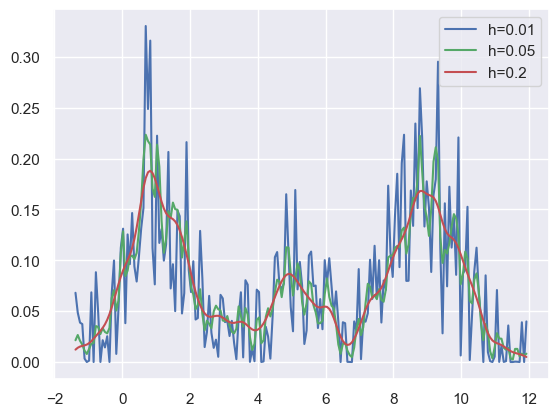

In [18]:
display_gaussian_kernel_density_1D(data, 0.01, 'b')
display_gaussian_kernel_density_1D(data, 0.05, 'g')
display_gaussian_kernel_density_1D(data, 0.2, 'r')

## 3) K-Nearest Neigbours classification

### 3.1) Generate Data

Using IRIS dataset from the sklearn library. Note that the data is 2-dimensional (two features). Plot the data.  

(<matplotlib.collections.PathCollection at 0x12ba57090>,
 <matplotlib.legend.Legend at 0x12bc69050>)

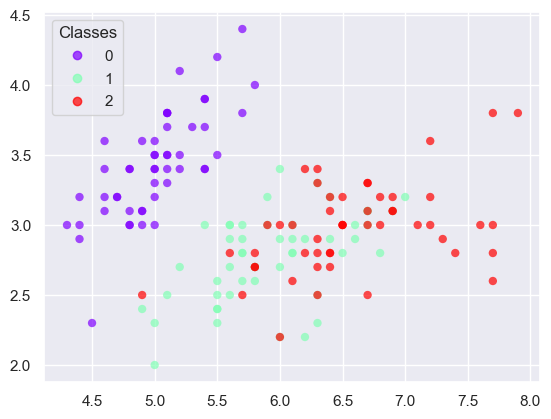

In [19]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

### 3.2) Classification function

write the `k_nearest_classification` function that takes a test data point `x`, training data points `data_x` and their associated classes `data_t`, the neighbours `k` and returns the predicted class for the test point `x`

In [20]:
def k_nearest_classification(x, data_x, data_t, k):
    grouped_points = zip(data_x, data_t)
    k_nearest = sorted(grouped_points, key=lambda d: np.dot(x-d[0], x-d[0]))[:k]
    k_nearest_classes = list(map(lambda a: a[1], k_nearest))
    
    counter = Counter(k_nearest_classes)
    return counter.most_common()[0][0]

### 3.3) Display results

Display the classification results for different values of `K`

In [21]:
def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.get_cmap('rainbow'))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

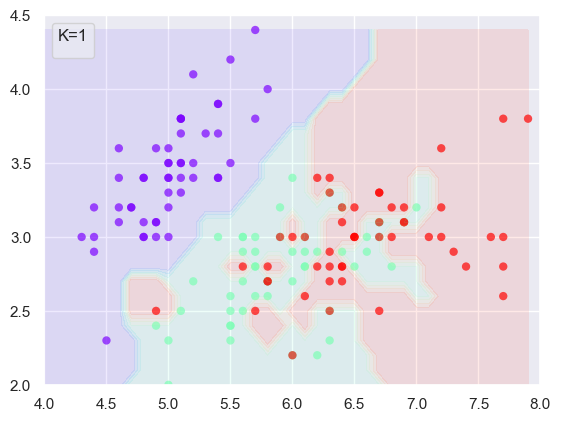

In [22]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 1))
plt.legend([], loc="upper left", title="K=1")

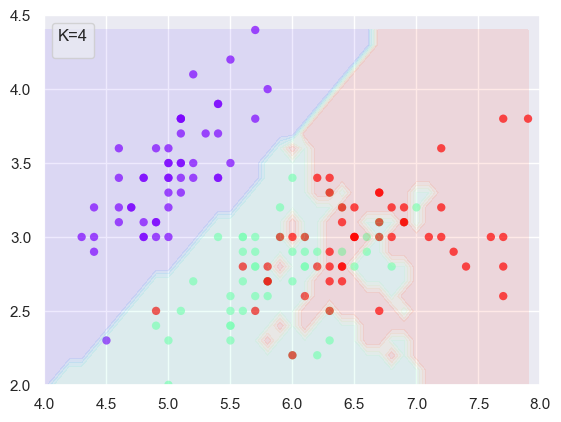

In [23]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 4))
plt.legend([], loc="upper left", title="K=4")

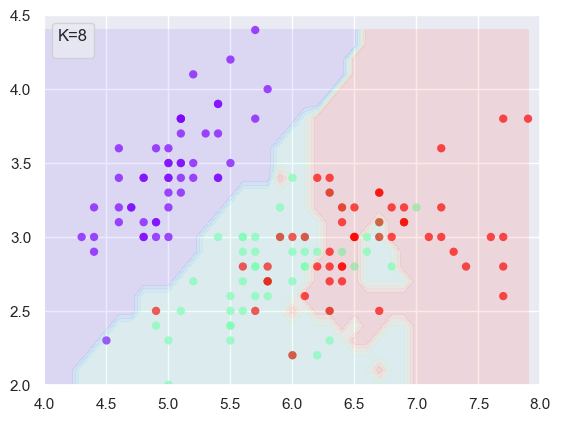

In [24]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 8))
plt.legend([], loc="upper left", title="K=8")

## 4) K-Means clustering

Write a function `k_means_step(mus_0, data_x)` that performs a SINGLE ITERATION of the K-means algorithm:

- Assign each data point in `data_x` to the closest mean in `mus_0`.

- Compute the new cluster means as the average of the points assigned to each cluster.

- Return the updated means `mus` and the cluster assignments `classes`.

In [25]:
def k_means_step(mus_0, data_x):
    
    
    def set_class(x):
        distance = list(map(
            lambda mu: np.dot(np.array(mu) - np.array(x), np.array(mu) - np.array(x)),
            mus_0
        ))
        
        return np.argmin(distance)
        
    
    
    classes = list(map(
        set_class, data_x
    ))
    
    mus = np.zeros([len(mus_0), len(data_x[0])])
    counts = np.zeros([len(mus), 1])
    
    for i, c in enumerate(classes):
        mus[c] += data_x[i]
        counts[c] += 1
    
    mus /= counts
    
    return mus, classes

`distortion_measure` takes means `mus`, `classes`, data points `data_x` and returns distortion of this classification (see slide 8 of lecture 8)

In [26]:
def distortion_measure(mus, classes, data_x):
    
    result = 0
    
    for i, c in enumerate(classes):
        
        x = data_x[i]
        mu = mus[c]
        distance = np.dot(np.array(mu) - np.array(x), np.array(mu) - np.array(x))
        result += distance
    
    return result

`optimize_k_means` takes initial means `mus_0` and data points `data_x`. The function iterates `k_means_step` until the cluster assignments no longer change between iterations, then returns the final means and assignments.

In [27]:
def optimize_k_means(mus_0, data_x):
    last_classes = None
    classes = []
    mus = mus_0

    while classes != last_classes:
        last_classes = classes
        mus, classes = k_means_step(mus, data_x)

    return mus, classes

### 4.1) Display results

In [28]:
k = 3
mus_0 = iris_x[:k]                 # first k points as initial centers
mus, classes = optimize_k_means(mus_0, iris_x)

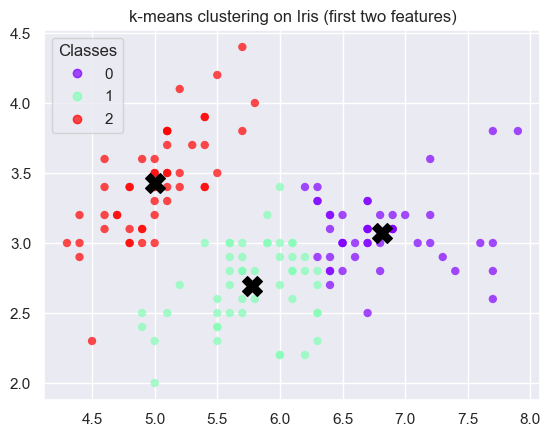

In [29]:
plt.figure()
plot_iris(legend=True, classes=classes)   # use k-means cluster assignments
plt.scatter(mus[:, 0], mus[:, 1], marker='X', s=200, c='black')  # mark centers
plt.title("k-means clustering on Iris (first two features)")
plt.show()


### Optional Exercise: Plot the progression of cluster means

Modify your K-means implementation so that after each iteration, you store the current means. Then, create a plot that shows how the cluster centers move step by step until convergence.

Hints:

Keep a list of means after each iteration.

Use scatter plots of the data points and plot the cluster centers (e.g. with X markers).

You may use different colors or arrows to show the trajectory of each cluster center.